# Imports and utility functions

In [4]:
import numpy as np
import glob
import pandas as pd
import vima
np.random.seed(0)

# Set up inputs to preprocessing

In [ ]:
# parameters
resolution = 10 # desired size of each pixel in microns
nmetamarkers = 10
repname = f'pca_k={nmetamarkers}_harmony'

# raw data location and target directory
rootdir = f'../../ALZ/alz-data'
outdir = f'{rootdir}/{resolution}u'

In [8]:
# raw data loader
def load(path):
    numeric = path.split('/')[-2] # replace this with code to determine the sample ID of each sample from its filepath
    donor = path.split('/')[-3]
    sid = f'{donor}_{numeric}'
    data = pd.read_csv(path) # replace this with code to load your transcript list from its filepath
    return sid, data

# define which raw data files to load
rawdir = f'{rootdir}/transcripts'
filepaths = glob.glob(f'{rawdir}/*/*/cellpose-detected_transcripts.csv')

# Rasterize and normalize transcript files

In [10]:
vima.pp.st.prepare_merfish(load=load,
                           filepaths=filepaths,
                           x_col='global_x',
                           y_col='global_y',
                           gene_col='gene',
                           outdir=outdir,
                           pixel_size=resolution,
                           plot=False)

Computing normalization factor...
	Processing sample 1/6: H333-333_567 (4.35M tx) → median 22.0 transcripts per pixel with >=10 transcripts
	Processing sample 2/6: H333-333_890 (5.27M tx) → median 21.0 transcripts per pixel with >=10 transcripts
	Processing sample 3/6: H234-222_234 (7.42M tx) → median 29.0 transcripts per pixel with >=10 transcripts
	Processing sample 4/6: H234-222_345 (5.29M tx) → median 31.0 transcripts per pixel with >=10 transcripts
	Processing sample 5/6: H123-345_456 (9.95M tx) → median 27.0 transcripts per pixel with >=10 transcripts
	Processing sample 6/6: 

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_4223/2657398033.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path) # replace this with code to load your transcript list from its filepath


H123-345_123 (9.88M tx) → median 29.0 transcripts per pixel with >=10 transcripts
Finding HVGs and dataset-wide mean and variance per gene...
	Processing sample 1/6: H333-333_567 has 4.35M transcripts. Using all 180 genes.
	Processing sample 2/6: H333-333_890 has 5.27M transcripts. Using all 180 genes.
	Processing sample 3/6: H234-222_234 has 7.42M transcripts. Using all 180 genes.
	Processing sample 4/6: H234-222_345 has 5.29M transcripts. Using all 180 genes.
	Processing sample 5/6: H123-345_456 has 9.95M transcripts. Using all 180 genes.
	Processing sample 6/6: 

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_4223/2657398033.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path) # replace this with code to load your transcript list from its filepath


H123-345_123 has 9.88M transcripts. Using all 180 genes.
Final number of genes used = 180
Rasterizing and normalizing...
Processing sample 1/6: H333-333_567
	Number of transcripts: 4.35M
	Making pixel list...343236 pixels.
	97097 pixels after QC.
	Log-normalizing and centering...
	restricting to 180 genes
	Making pixel matrix...done. shape: (819, 829, 180)
Processing sample 2/6: H333-333_890
	Number of transcripts: 5.27M
	Making pixel list...350650 pixels.
	122999 pixels after QC.
	Log-normalizing and centering...
	restricting to 180 genes
	Making pixel matrix...done. shape: (833, 823, 180)
Processing sample 3/6: H234-222_234
	Number of transcripts: 7.42M
	Making pixel list...206020 pixels.
	136952 pixels after QC.
	Log-normalizing and centering...
	restricting to 180 genes
	Making pixel matrix...done. shape: (1035, 574, 180)
Processing sample 4/6: H234-222_345
	Number of transcripts: 5.29M
	Making pixel list...159955 pixels.
	96670 pixels after QC.
	Log-normalizing and centering...
	r

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_4223/2657398033.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path) # replace this with code to load your transcript list from its filepath


Processing sample 6/6: H123-345_123
	Number of transcripts: 9.88M
	Making pixel list...356288 pixels.
	178807 pixels after QC.
	Log-normalizing and centering...
	restricting to 180 genes
	Making pixel matrix...done. shape: (787, 982, 180)


# PCA and integration with harmony

creating metapixels prior to PCA


6it [00:07,  1.18s/it]


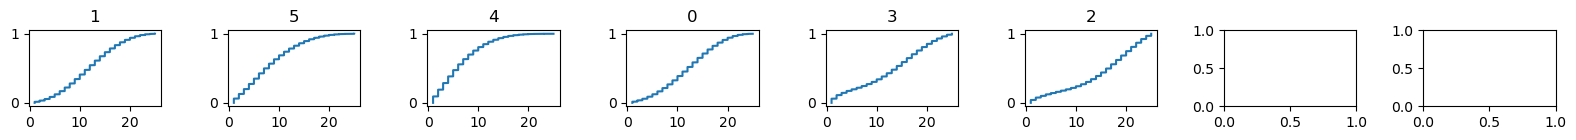

merging and standardizing metapixels


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


(1904089, 180)
performing PCA


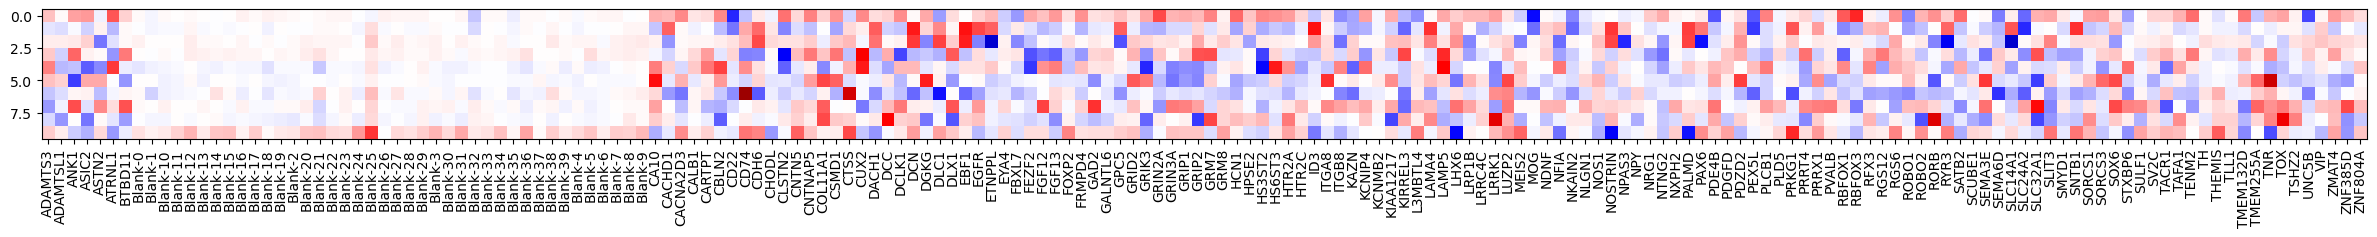

reading in pixels


100%|█████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.15it/s]


applying dimensionality reduction


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


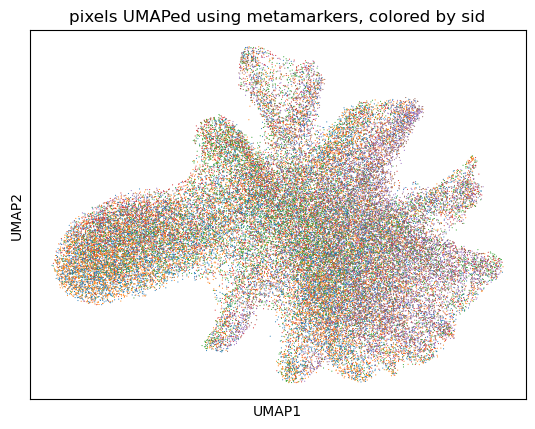

=== running harmony ===


Loading required package: Rcpp
code for methods in class “Rcpp_harmony” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)
code for methods in class “Rcpp_harmony” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)

Attaching package: ‘arrow’

The following object is masked from ‘package:utils’:

    timestamp

Detected available cores: 12
Requested ncores = 32 but only 12 available. Using ncores = 12.
Transposing data matrix


Input file: /var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/tmppknmmwne.feather 
Metadata: sid 
Running Harmony...


Initializing state using k-means centroids initialization
Harmony 1/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Harmony 2/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Harmony 3/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
*

Harmony completed successfully.
Writing output to: /var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/tmppknmmwne_harmony.feather 
Done.
=== finished running harmony ===


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


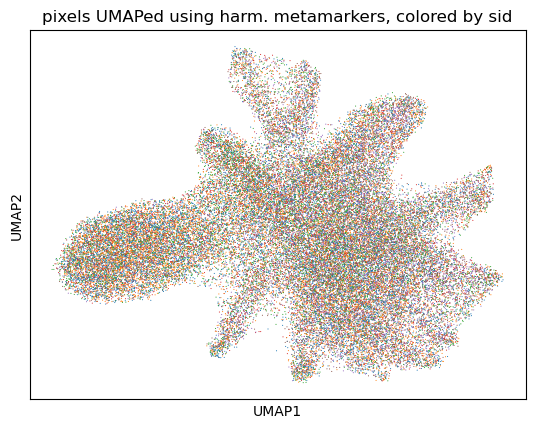

100%|█████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.08it/s]


In [ ]:
# perform qc and convert markers to meta-markers
allpixels_pca = vima.pp.preprocess(outdir, repname, nmetamarkers=nmetamarkers)

# harmonize the meta-markers and write the results
harmpixels = vima.pp.harmonize(allpixels_pca, '/Users/yakir/miniconda3/envs/Renv/bin/Rscript')
vima.pp.write_harmonized(outdir, repname, harmpixels)

all PCs of one sample


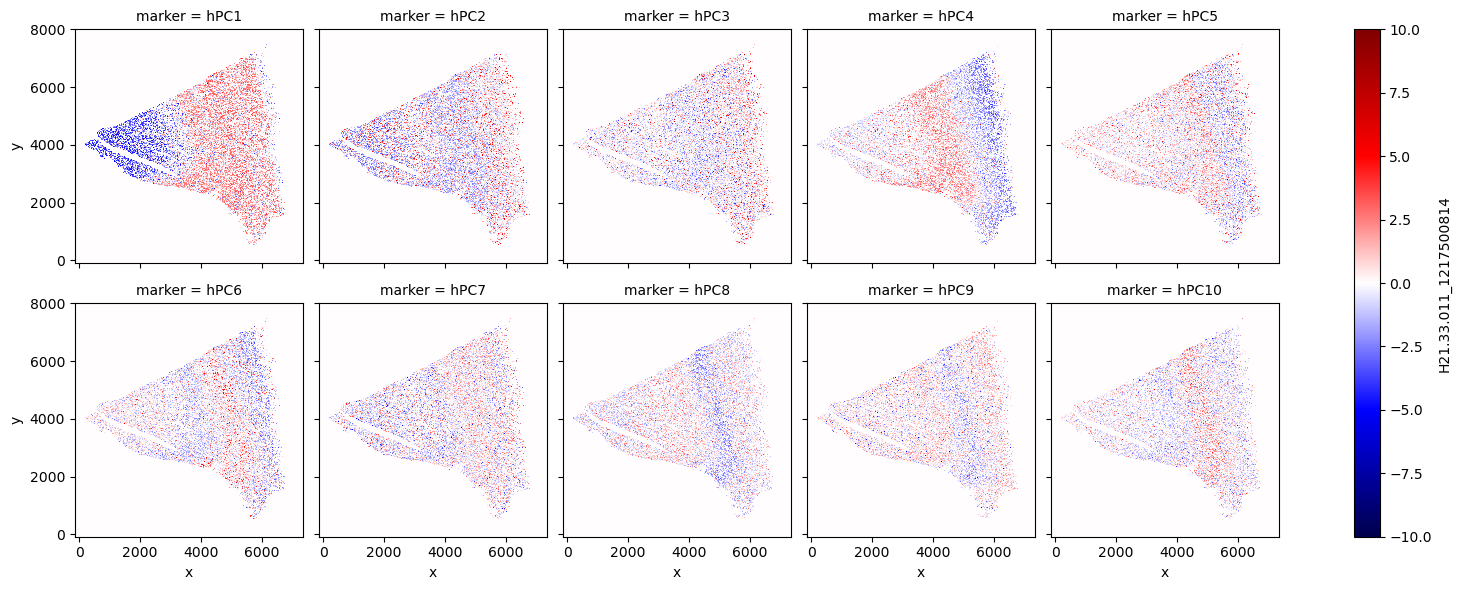

histogram of each pc
0123456789

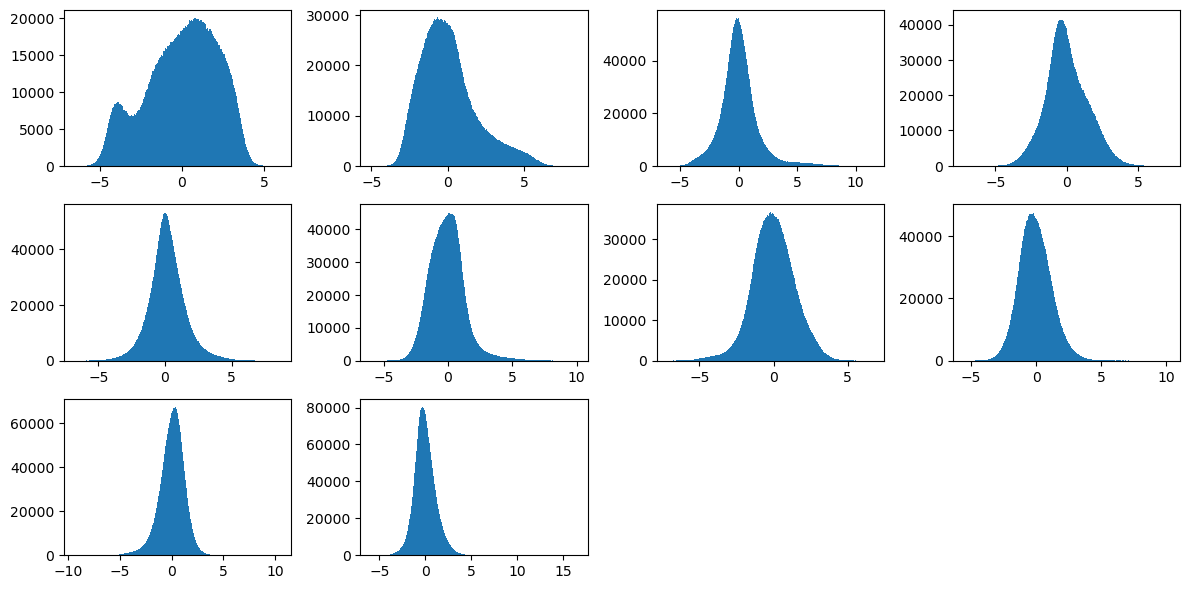

PC1 of several samples


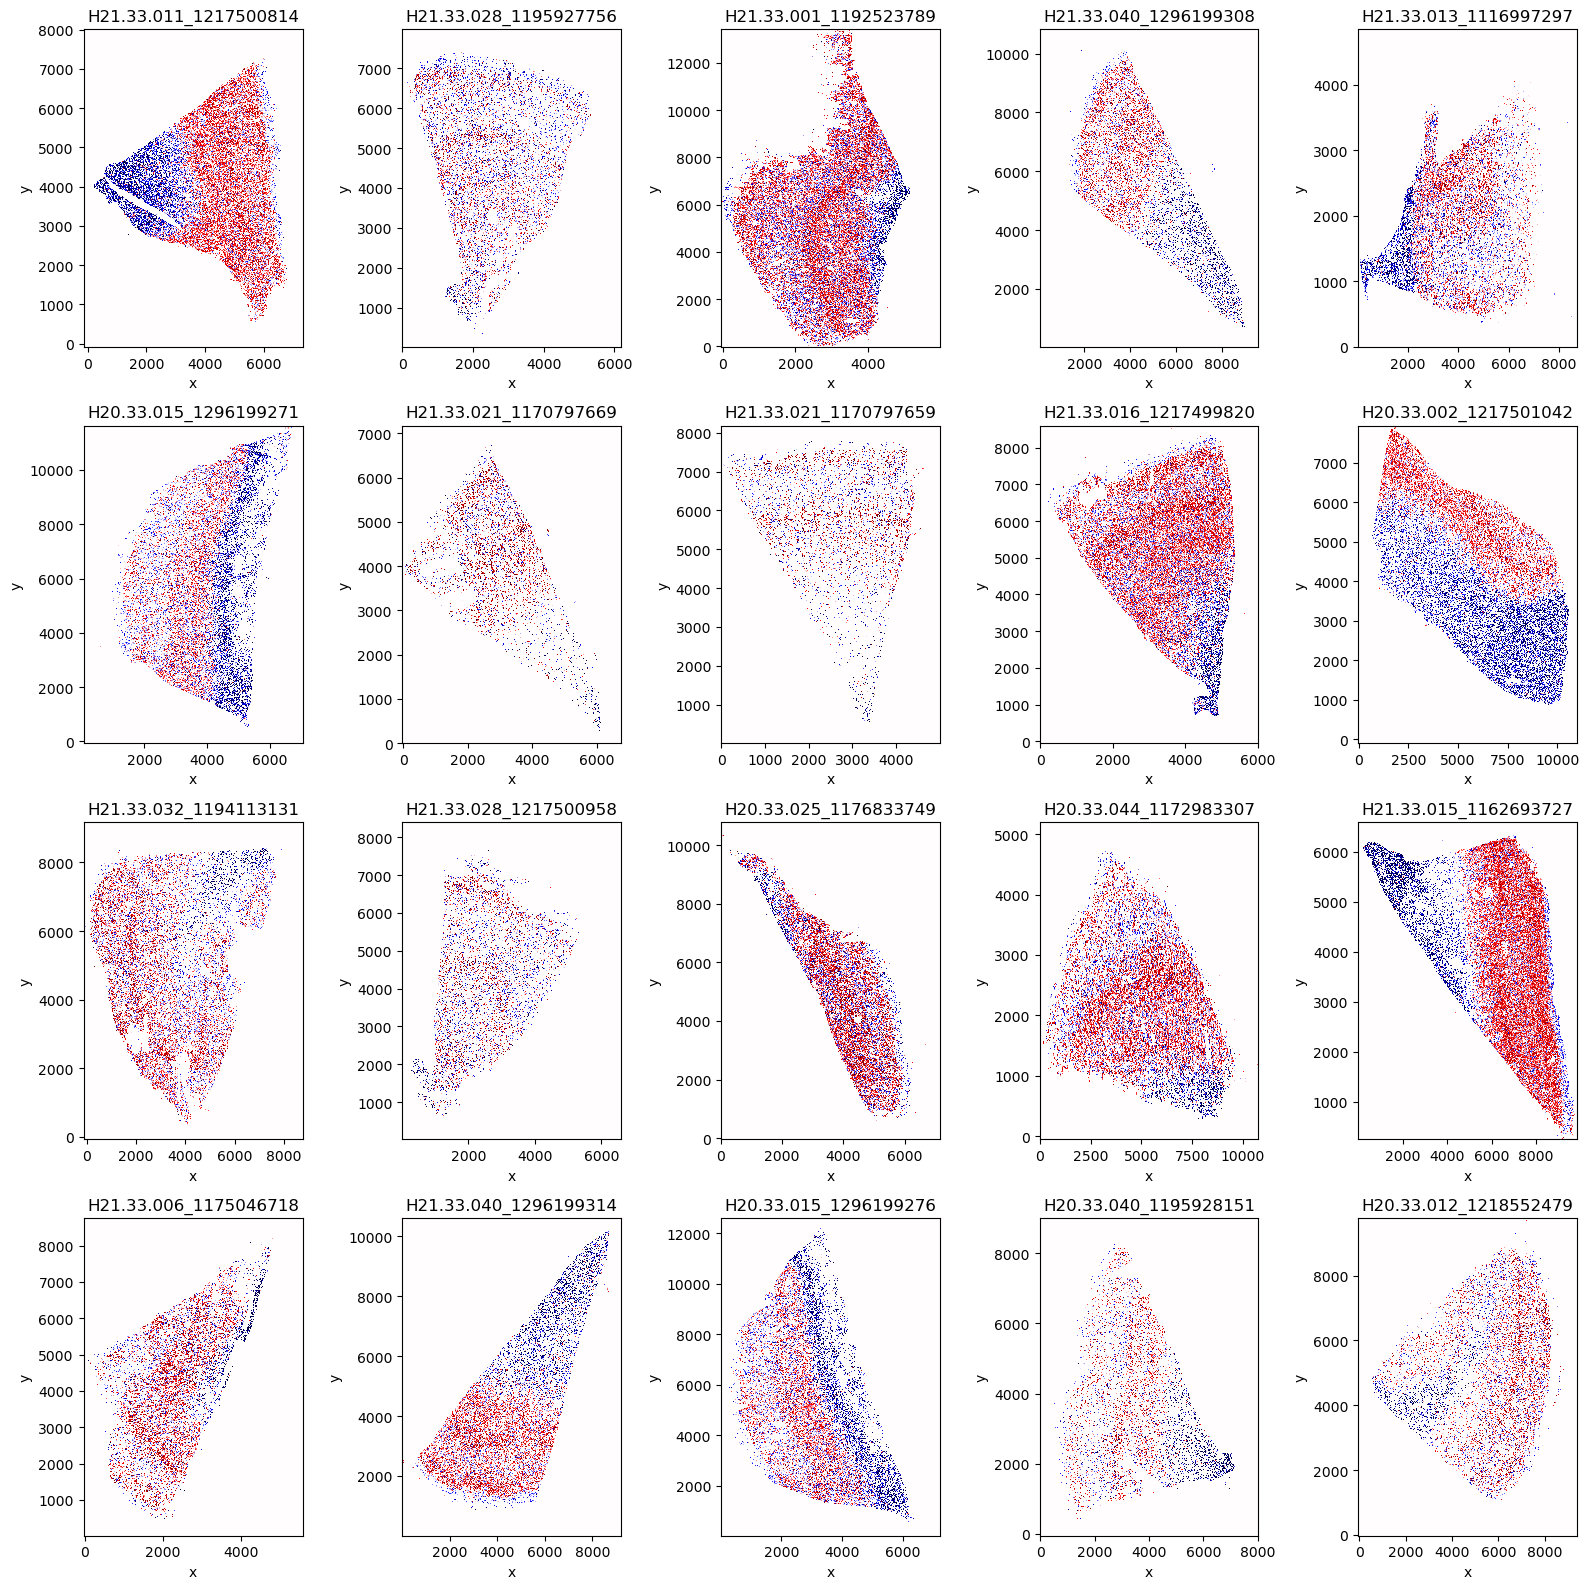

In [4]:
# visual sanity checks
vima.pp.sanity_checks(outdir, repname)